## 1주차: Basic

### 과제 1
`temp_samples = [72, 75, 79, 88, 91, 85]` 리스트를 만들고, **85 초과 값만** 출력하세요.

### 과제 2
`is_overheat(temp)` 함수를 작성하고, `temp >= 90`이면 `True`, 아니면 `False`를 반환하게 만드세요.

### 과제 3
NumPy를 사용해 `temp_samples`의 최솟값/최댓값/평균을 계산하세요.

In [ ]:
# 1
temp_samples = [72, 75, 79, 88, 91, 85]
# print([tmp for tmp in temp_samples if tmp > 85])
for temp in temp_samples:
    if temp > 85: print(temp)
# 2
def is_overheat(temp): return temp >= 90

# 3
import numpy as np
nptemp_samples = np.array(temp_samples)
print(nptemp_samples.min(), nptemp_samples.max(), nptemp_samples.mean())


### 미니 미션

아래 조건을 만족하는 코드를 작성해보세요.

- `speed = np.array([35, 42, 51, 49, 62, 71, 68, 55])`
- 속도 50 이상만 추출
- 추출된 값의 평균 계산
- 평균이 60 이상이면 `"고속 주행 구간"` 출력, 아니면 `"일반 주행 구간"` 출력

추가 도전:
- 인덱스까지 함께 출력해 어떤 시점에서 50 이상이었는지 확인

In [ ]:
import numpy as np

speed = np.array([35, 42, 51, 49, 62, 71, 68, 55])
# mask = speed >= 50
# speed[mask]
if speed[speed >= 50].mean() >= 60: print("고속 주행 구간")
else : print("일반 주행 구간")
print("위치:", np.where(speed >= 50)[0]) # np.where는 튜플로 반환하므로 [0]으로 위치 배열을 추출

# idx, = np.where(speed >= 50)
# print("위치:", idx)

## 2주차: IMU

### 필터링 기법
1. **Average Filter**: 전체 데이터의 평균값으로 필터링
2. **Moving Average Filter**: 슬라이딩 윈도우를 사용한 이동 평균
3. **Exponential Moving Average Filter**: 가중 평균을 사용한 지수 이동 평균

In [ ]:

class MotionSensorProcessor:
    """차량 모션 센서 데이터 처리 클래스"""

    def __init__(self):
        self.data = {}

    # 1. 평균 필터
    def average_filter(self, data: np.ndarray) -> np.ndarray: # 변수명은 ndarray임. np.array([])는 전환해주는 함수

        filtered_data = np.zeros_like(data)
        for i in range(len(data)):
            filtered_data[i] = data[:i+1].mean() #numpy 확실하니까 가능.
            # filtered_data[i] = np.mean(data[:i+1])

        return filtered_data
    
    # 2. 이동 평균 필터    
    def mov_avg_filter(self, data:np.ndarray, win_size: int =5) -> np.ndarray:
        if win_size <= 0: raise ValueError("윈도우 크기는 양수여야 합니다.")
        
        filtered_data = np.zeros_like(data, dtype=float) 
        # .mean()이 float을 뱉어도 filtered_data가 float여야 함. 
        # 만약 data가 int면 int로 저장됨
        for i in range(len(data)):
            start_idx = max(0, i + 1 - win_size)
            end_idx = i+1
            filtered_data[i] = data[start_idx:end_idx].mean()
        return filtered_data
    
    # 3. 지수 이동 평균 필터
    def exp_mov_avg_filter(self, data: np.ndarray, alpha: float = 0.3) -> np.ndarray:

        if alpha <= 0 or alpha > 1: raise ValueError("alpha 값은 0과 1 사이여야 합니다.")
        
        filtered_data = np.zeros_like(data, dtype=float)
        filtered_data[0] = data[0]
        
        for i in range(1, len(data)):
            filtered_data[i] = (1 - alpha) * filtered_data[i-1] + alpha * data[i]
        return filtered_data

### 3. Pulse Counting Method

일정 시간 동안의 펄스 개수로 속도 추정

**M-Method**: N = 펄스 개수, ΔT = 고정 시간 간격

### 수식
```
ω = 2π × N / (Z × ΔT)
```
- ω: 각속도 (rad/s)
- N: 샘플링 주기 동안의 펄스 수
- Z: 회전당 펄스 수 (pulses per revolution)
- ΔT: 샘플링 주기 (sec)


In [ ]:
def pulse_counting_method(self, time:np.ndarray, pulses:np.ndarray, pulses_per_revolution: int, counting_time_interval: float) ->np.ndarray:

	est_ang_vel = np.zeros(len(time))

	tmp_pulse_count = 0
	curr_est_ang_vel = 0.0
	prev_time = time[0] # 미리 초기화
	prev_pulse =pulses[0] # 미리 초기화

	for idx in range(1, len(time)):
		if pulses[idx] == 1 and prev_pulse == 0: # 스칼라간의 비교는 'and'
			tmp_pulse_count += 1

		delta_time = time[idx] - prev_time
		
		if delta_time >= counting_time_interval:
			curr_est_ang_vel = tmp_pulse_count * 2 * np.pi / (pulses_per_revolution * counting_time_interval)
			tmp_pulse_count = 0
			prev_time = time[idx]
		 
		est_ang_vel[idx] = curr_est_ang_vel
		prev_pulse = pulses[idx]
		
	return est_ang_vel

### 4. Pulse Timing Method

펄스 간 시간 간격으로 속도 추정

**T-Method**: N = 1, ΔT = 펄스 간 시간 간격  

### 수식
```
ω = 2π / (Z × ΔTd)
```
- ω: 각속도 (rad/s)
- Z: 회전당 펄스 수 (pulses per revolution)
- ΔTd: 펄스 간격


In [ ]:
def pulse_timing_method(self, time: np.ndarray, pulses: np.ndarray, pulses_per_revolution: int) ->np.ndarray:

	prev_time = time[0]
	prev_pulse = pulses[0]
	curr_est_ang_vel = 0.0
	est_ang_vel = np.zeros(len(time))

	for idx in range(1,len(time)):
		if pulses[idx] == 1 and prev_pulse == 0: 
			delta_time = time[idx] - prev_time

			if delta_time < 1e-3:
				delta_time = 1e-3

			curr_est_ang_vel = 2 * np.pi / (pulses_per_revolution * delta_time)
			prev_time = time[idx]
	
		est_ang_vel[idx] = curr_est_ang_vel
		prev_pulse = pulses[idx]

	return est_ang_vel

### 5. DR(Dead Reckoning)을 통한 위치 추정

Dead Reckoning(DR): **IMU 센서(자이로의 yaw rate)와 속도 정보(Wheel Odometry를 통해 취득)를 활용하여 차량의 위치를 적분적으로 추정하는 방법**
GPS/INS 데이터로부터 얻은 초기 위치와 속도를 바탕으로, IMU yaw rate와 속도를 적분하여 DR 경로를 계산

**장점**: GPS 없이도 연속적으로 위치 추정 가능

**단점**: 센서 노이즈와 바이어스로 인해 시간이 지남에 따라 누적 오차 발생

### DR 위치 추정 과정
1. **센서 데이터 동기화**  
   - IMU 시간축 기준으로 Wheel Odometry 속도 데이터를 보간(interpolation)  
   - `np.interp()`를 사용하여 imu_time 기준 속도 배열 생성  

2. **초기 상태 설정**  
   - 시작 위도, 경도, 방위각(azimuth) 추출  
   - 지구 반경 (R = 6378137m) 사용하여 위도/경도 변화량 계산 준비  

3. **방향(Heading) 업데이트**  
   - IMU yaw rate $(\omega)$ 적분  
   
   $\theta_k = \theta_{k-1} + \omega \cdot \Delta t$  

4. **변위 계산**  
   - 선속도 ($v$) 와 방향 $(\theta)$ 를 이용한 이동 거리 계산  
   
   $dx = v \cdot \cos(\theta) \cdot \Delta t$  
   
   $dy = v \cdot \sin(\theta) \cdot \Delta t$  

5. **위도/경도 업데이트**  
   - 지구 반경을 고려한 위도, 경도 증분 계산  
   
   $\Delta \phi = \frac{dy}{R}, \quad$
   $\Delta \lambda = \frac{dx}{R \cdot \cos(\phi)}$
     
   - 최종 위치 누적

   $\phi_k = \phi_{k-1} + \Delta \phi, \quad$
   $\lambda_k = \lambda_{k-1} + \Delta \lambda$


In [ ]:
def calc_dr_traj(self, imu_data: dict, inspvax_data: dict) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    imu_time = np.array(imu_data['time'])
    imu_yaw_rate = np.array([d.angular_velocity.z for d in imu_data['data']])
    
    inspvax_time = np.array(inspvax_data['time'])
    north_vel    = np.array([d.north_velocity for d in inspvax_data['data']])
    east_vel     = np.array([d.east_velocity for d in inspvax_data['data']])
    
    start_time = imu_time[0]
    imu_time -= start_time
    inspvax_time -= start_time
    
    velocity_interp = np.interp(imu_time, inspvax_time, np.sqrt(north_vel**2 + east_vel**2))
    current_vel = 0.0
    
    R = 6378137.0
    
    d0 = inspvax_data['data'][0]
    lat_rad = np.deg2rad(d0.latitude)
    lon_rad = np.deg2rad(d0.longitude)
    theta   = np.deg2rad(90 - d0.azimuth)
    
    N = len(imu_time)
    dr_lat = np.zeros(N, float)
    dr_lon = np.zeros(N, float)
    
    dr_lat[0] = np.rad2deg(lat_rad)
    dr_lon[0] = np.rad2deg(lon_rad)
    
    for i in range(1,N):
        dt = imu_time[i] - imu_time[i-1]
        theta += imu_yaw_rate[i] * dt
        current_vel = velocity_interp[i]
        dx = current_vel * np.cos(theta) * dt
        dy = current_vel * np.sin(theta) * dt
        
        lat_rad += dy / R
        lon_rad += dx / (R * np.cos(lat_rad))
        
        dr_lat[i] = np.rad2deg(lat_rad)
        dr_lon[i] = np.rad2deg(lon_rad)
        
    return dr_lat, dr_lon, imu_time

## 3주차:GNSS

### 1. NMEA 데이터 분석

NMEA (National Marine Electronics Association) 0183은 GPS 수신기에서 가장 널리 사용되는 표준 통신 프로토콜입니다. 
이번 실습에서는 GGA와 RMC 메시지를 중심으로 NMEA 데이터를 분석합니다.

### NMEA 메시지 종류
- **GGA (Global Positioning System Fix Data)**: 위치, 고도, HDOP, 위성 수 등
- **RMC (Recommended Minimum)**: 위치, 속도, 방향, 날짜, 상태 등

In [ ]:
    def _parse_gga(self, line: str) -> Optional[Dict]:
        """
        GGA 메세지 구조: $GPGGA,<time>,<latitude>,<latitude_hemisphere>,<longitude>,<longitude_hemisphere>,
        <fix_quality>,<num_satellites>,<hdop>,<altitude>,<altitude_unit>,<geoid_height>,<checksum>
        """
        try:
            parts = line.split(',')
            if len(parts) < 15:
                return None
                
            # 위도 변환
            lat_str = parts[2] # 위도 문자열 추출 - parts 사용
            lat_hemisphere = parts[3] # 위도 방향 추출
            if lat_str and lat_hemisphere:
                lat_deg = int(lat_str[:2])
                lat_min = float(lat_str[2:])
                latitude = lat_deg + lat_min / 60.0
                if lat_hemisphere == 'S':
                    latitude = -latitude
            else:
                latitude = None
                
            # 경도 변환
            lon_str = parts[4] # 경도 문자열 추출
            lon_hemisphere = parts[5] # 경도 방향 추출
            if lon_str and lon_hemisphere:
                lon_deg = int(lon_str[:3])
                lon_min = float(lon_str[3:])
                longitude = lon_deg + lon_min / 60.0
                if lon_hemisphere == 'W':
                    longitude = -longitude
            else:
                longitude = None
                
            return {
                'time': parts[1], # UTC 시간 추출
                'latitude': latitude,
                'longitude': longitude,
                'fix_quality': int(parts[6]) if parts[6] else 0, # FIX 품질 추출
                'num_satellites': int(parts[7]) if parts[7] else 0, # 위성 수 추출
                'hdop': float(parts[8]) if parts[8] else 0.0, # HDOP 추출
                'altitude': float(parts[9]) if parts[9] else 0.0, # 고도 추출
                'altitude_unit': parts[10] if parts[10] else '', # 고도 단위 추출
                'geoid_height': float(parts[11]) if parts[11] else 0.0 # 지구 고도 추출 (undulation)
            }
        except (ValueError, IndexError):
            return None
    
    def _parse_rmc(self, line: str) -> Optional[Dict]:
        """
        RMC 메세지 구조: $GPRMC,<time>,<status>,<latitude>,<latitude_hemisphere>,<longitude>,<longitude_hemisphere>,<speed>,<course>
        ,<date>,<magnetic_variation>,<magnetic_variation_hemisphere>,<mode>,<checksum>
        """
        try:
            parts = line.split(',')
            if len(parts) < 12:
                return None
                
            # 위도 변환
            lat_str = parts[3] # 위도 문자열 추출
            lat_hemisphere = parts[4] # 위도 방향 추출
            if lat_str and lat_hemisphere:
                lat_deg = int(lat_str[:2])
                lat_min = float(lat_str[2:])
                latitude = lat_deg + lat_min / 60.0
                if lat_hemisphere == 'S':
                    latitude = -latitude
            else:
                latitude = None
                
            # 경도 변환
            lon_str = parts[5] # 경도 문자열 추출
            lon_hemisphere = parts[6] # 경도 방향 추출
            if lon_str and lon_hemisphere:
                lon_deg = int(lon_str[:3])
                lon_min = float(lon_str[3:])
                longitude = lon_deg + lon_min / 60.0
                if lon_hemisphere == 'W':
                    longitude = -longitude
            else:
                longitude = None
                
            return {
                'time': parts[1], # UTC 시간 추출
                'status': parts[2], # 상태 추출
                'latitude': latitude,
                'longitude': longitude,
                'speed_knots': float(parts[7]) if parts[7] else 0.0, # 속도 추출
                'course': float(parts[8]) if parts[8] else 0.0, # 방향 추출 (Track true)
                'date': parts[9] # 날짜 추출
            }
        except (ValueError, IndexError):
            return None

### 4. 좌표 변환 실습 (WGS84 ↔ ENU)

전역 좌표계(WGS84)와 지역 좌표계(ENU) 간 변환

### 좌표계 설명
- **WGS84**: 세계 측지계, GPS가 사용하는 전역 좌표계 (위도, 경도, 고도)
- **ENU**: East-North-Up, 지역 직교 좌표계 (동쪽, 북쪽, 위쪽)

### 변환 과정
1. **WGS84 → ENU**: 글로벌 좌표를 로컬 좌표로 변환
2. **ENU → WGS84**: 로컬 좌표를 다시 글로벌 좌표로 역변환
3. **정확도 검증**: 원본과 재변환 결과 비교

### 변환 수식
**WGS84 → ENU:**
```
E = Δlon × (N + h) × cos(φ₀)
N = Δlat × (M + h)  
U = Δh
```

**ENU → WGS84:**
```
Δlat = N / (M + h)
Δlon = E / ((N + h) × cos(φ₀))
Δh = U
```

여기서 M은 자오선 곡률반지름, N은 수직 곡률반지름입니다.

In [ ]:
import numpy as np
def wgs84_to_enu(self, llh: np.ndarray, ref_llh: np.ndarray) -> np.ndarray:
    enu = np.zeros_like(llh, float)
    
    ref_lat = np.deg2rad(ref_llh[0])
    ref_lon = np.deg2rad(ref_llh[1])
    ref_height  = ref_llh[2]
    
    meridional_r = self.meridional_radius(ref_llh[0])
    normal_r    = self.normal_radius(ref_llh[0])
    
    lat = np.deg2rad(llh[:, 0])
    lon = np.deg2rad(llh[:, 1])
    height = (llh[:,2])
    
    delta_lat_rad = lat - ref_lat
    delta_lon_rad = lon - ref_lon
    delta_height  = height - ref_height
    
    enu[:, 0] = delta_lon_rad * (normal_r + ref_height) * np.cos(ref_lat)
    enu[:, 1] = delta_lat_rad * (meridional_r + ref_height)
    enu[:, 2] = delta_height
    
    return enu
def enu_to_wgs84(self, enu: np.ndarray, ref_llh: np.ndarray) -> np.ndarray:
    llh = np.zeros_like(enu, float)
    
    ref_lat = np.deg2rad(ref_llh[0])
    ref_lon = np.deg2rad(ref_llh[1])
    ref_height = ref_llh[2]
    
    meridional_r = self.meridional_radius(ref_llh[0])
    normal_r = self.normal_radius(ref_llh[0])
    
    delta_lon_rad = enu[:, 0] / ((normal_r + ref_height) * np.cos(ref_lat))
    delta_lat_rad = enu[:, 1] / (meridional_r + ref_height)
    delta_height = enu[:, 2]
    
    llh[:, 0] = np.rad2deg(ref_lat + delta_lat_rad)
    llh[:, 1] = np.rad2deg(ref_lon + delta_lon_rad)
    llh[:, 2] = ref_height + delta_height
    
    return llh

## 4주차: LiDAR 

LiDAR 파트는 `custom_lidar.py`의 TODO 함수들을 흐름대로 정리하면 크게 다음 4단계로 볼 수 있습니다.

- **ROI Extraction**: 관심 있는 공간 범위만 남기기
- **k-NN Search**: 쿼리 점과 가까운 이웃 찾기
- **Least Squares Fitting**: 직선과 구를 최소 자승법으로 추정하기
- **RANSAC Helpers**: 샘플링, 모델 추정, 거리 계산, 인라이어 분류


### 1. ROI(Region of Interest) 추출

포인트 클라우드 전체를 다 쓰지 않고, 필요한 범위만 남기는 단계입니다.

핵심 아이디어는 축별 조건 마스크를 만든 뒤, 이를 AND 연산으로 합치는 것입니다.

- `x_mask`: X축 범위 필터
- `y_mask`: Y축 범위 필터
- `z_mask`: Z축 범위 필터
- `roi_mask = x_mask & y_mask & z_mask`


In [ ]:
import open3d as o3d
import numpy as np
from typing import Tuple

def custom_extract_roi(
    pcd: o3d.geometry.PointCloud,
    x_range: Tuple[float, float] = (-20, 20),
    y_range: Tuple[float, float] = (-20, 20),
    z_range: Tuple[float, float] = (-3, 3),
) -> Tuple[o3d.geometry.PointCloud, o3d.geometry.PointCloud]:
    
    points = np.array(pcd.points)
    x_mask = (points[:, 0] >= x_range[0]) & (points[:, 0] <= x_range[1])
    y_mask = (points[:, 1] >= y_range[0]) & (points[:, 1] <= y_range[1])
    z_mask = (points[:, 2] >= z_range[0]) & (points[:, 2] <= z_range[1])
    
    roi_mask = x_mask & y_mask & z_mask
    roi_points = points[roi_mask]
    roi_outliers = points[~roi_mask]
    
    roi_pcd = o3d.geometry.PointCloud()
    roi_pcd.points = o3d.utility.Vector3dVector(roi_points)
    
    roi_outliers_pcd = o3d.geometry.PointCloud()
    roi_outliers_pcd.points = o3d.utility.Vector3dVector(roi_outliers)
    
    if len(pcd.colors) > 0:
        colors = np.array(pcd.colors)
        roi_colors = colors[roi_mask]
        roi_pcd.colors = o3d.utility.Vector3dVector(roi_colors)
        
        roi_outliers_colors = colors[~roi_mask]
        roi_outliers_pcd.colors = o3d.utility.Vector3dVector(roi_outliers_colors)
        
    return roi_pcd, roi_outliers_pcd
        
        
    
    

### 2. Brute-force k-NN 검색

KD-Tree를 쓰기 전 가장 단순한 최근접 이웃 탐색입니다.

과정은 다음과 같습니다.

1. 모든 점과 쿼리 점 사이 거리 계산
2. 거리 기준 정렬
3. 앞에서부터 `k`개 선택


In [ ]:
def custom_brute_force_search(
    pcd: o3d.geometry.PointCloud,
    query: np.ndarray,
    k: int,
) -> Tuple[np.ndarray, np.ndarray]:
    
    points = np.array(pcd.points)
    query = np.array(query)
    
    distances = np.linalg.norm(points - query, axis = 1)
    sorted_indices = np.argsort(distances)
    
    k_indices = sorted_indices[:k]
    k_distances = distances[k_indices]
    return k_indices, k_distances

### 3. Least Squares 직선 피팅

직선 방정식 `y = ax + b`를 최소 자승법으로 추정합니다.

행렬 형태로 쓰면 `H @ params = b` 이고, 정규 방정식은 아래와 같습니다.

```
params = (H^T H)^(-1) H^T b
```

여기서 `params = [a, b]^T` 입니다.


In [ ]:
def custom_least_squares_line_fitting(pcd: o3d.geometry.PointCloud) -> np.ndarray:
    points = np.array(pcd.points)
    x, y = points[:, 0], points[:, 1]
    n = len(points)

    H = np.column_stack([x, np.ones(n)])
    b = y

    HtH = H.T @ H
    Ht_b = H.T @ b

    try:
        inv_HtH = np.linalg.inv(HtH)
    except np.linalg.LinAlgError:
        inv_HtH = np.linalg.pinv(HtH)

    return inv_HtH @ Ht_b


### 4. Least Squares 구 피팅

구 방정식은 비선형이지만, 전개 후 선형 형태로 바꿔 최소 자승법을 적용할 수 있습니다.

- 중심: `(cx, cy, cz)`
- 반지름: `r`
- 마지막에 `radius_squared = cx^2 + cy^2 + cz^2 + d` 로 반지름 복원


In [ ]:
def custom_least_squares_sphere_fitting(
    pcd: o3d.geometry.PointCloud,
) -> Tuple[np.ndarray, float]:
    points = np.array(pcd.points)
    x, y, z = points[:, 0], points[:, 1], points[:, 2]
    n = len(points)

    H = np.column_stack([x, y, z, np.ones(n)])
    b = x ** 2 + y ** 2 + z ** 2

    HtH = H.T @ H
    Ht_b = H.T @ b

    try:
        inv_HtH = np.linalg.inv(HtH)
    except np.linalg.LinAlgError:
        inv_HtH = np.linalg.pinv(HtH)

    params = inv_HtH @ Ht_b
    cx, cy, cz = params[0] / 2, params[1] / 2, params[2] / 2
    d = params[3]

    radius_squared = cx ** 2 + cy ** 2 + cz ** 2 + d
    radius = np.sqrt(max(0, radius_squared))
    center = np.array([cx, cy, cz], dtype=float)
    return center, radius


### 5. RANSAC용 샘플링과 모델 추정

RANSAC은 매 반복마다 일부 점만 뽑아서 임시 모델을 만들고, 그 모델이 얼마나 많은 인라이어를 가지는지 평가합니다.

여기서는 다음 보조 함수들이 필요합니다.

- `custom_ransac_sample_points`: 중복 없이 랜덤 샘플링
- `custom_fit_line_from_samples`: 샘플 점들로 직선 추정
- `custom_fit_sphere_from_samples`: 샘플 점들로 구 추정


In [ ]:
def custom_ransac_sample_points(
    pcd: o3d.geometry.PointCloud,
    n_samples: int,
) -> Tuple[np.ndarray, np.ndarray]:
    points = np.array(pcd.points)
    n_points = len(points)

    sampled_indices = np.random.choice(n_points, size=n_samples, replace=False)
    sampled_points = points[sampled_indices]
    return sampled_points, sampled_indices

### 6. 거리 계산과 Inlier / Outlier 분류

RANSAC에서 모델을 하나 세웠다면, 이제 모든 점이 그 모델에 얼마나 잘 맞는지 거리로 평가합니다.

- 직선 거리: `|ax - y + b| / sqrt(a^2 + 1)`
- 구 거리: `|distance_to_center - radius|`
- threshold보다 작으면 inlier, 크거나 같으면 outlier


In [ ]:
def custom_compute_line_distances(
    pcd: o3d.geometry.PointCloud,
    line_params: np.ndarray,
) -> np.ndarray:
    points = np.array(pcd.points)
    x, y = points[:, 0], points[:, 1]
    a, b = line_params

    numerator = np.abs(a * x - y + b)
    denominator = np.sqrt(a ** 2 + 1)
    return numerator / denominator


def custom_compute_sphere_distances(
    pcd: o3d.geometry.PointCloud,
    center: np.ndarray,
    radius: float,
) -> np.ndarray:
    points = np.array(pcd.points)
    distances_to_center = np.linalg.norm(points - center, axis=1)
    return np.abs(distances_to_center - radius)


def custom_find_inliers_outliers(
    distances: np.ndarray,
    threshold: float,
) -> Tuple[np.ndarray, np.ndarray]:
    inlier_indices = np.where(distances < threshold)[0]
    outlier_indices = np.where(distances >= threshold)[0]
    return inlier_indices, outlier_indices


## 5주차: Radar

Radar 파트는 `custom_radar.py`의 TODO 함수들을 흐름대로 정리하면 크게 다음 4단계로 볼 수 있습니다.

- **Noise Filtering**: Statistical Outlier Removal — KD-Tree 기반 K-NN으로 아웃라이어 제거
- **Translation**: 포인트 클라우드 평행 이동
- **Rotation**: Roll·Pitch·Yaw 회전 행렬 생성 및 적용
- **Transformation Matrix**: 4×4 행렬로 R과 t를 통합해 변환
- **DBSCAN Clustering**: 밀도 기반 군집화 직접 구현

### 1. Radius Outlier Removal (ROR)

각 포인트의 반지름 안에 이웃이 몇개나 있는지 개수 세기

1. 반지름 안에 이웃이 몇개나 있는지
2. `반지름 내 이웃 수 < min_nb_points` 인 점 = 아웃라이어
4. 인라이어만 남겨 반환

In [ ]:
def custom_radius_outlier_removal(pcd, radius: float = 0.05, min_nb_points: int = 16):
    points = np.asarray(pcd.points)
    inlier_mask = np.zeros(len(points), dtype=bool)
    for i, point in enumerate(points):
        distances = np.linalg.norm(points - point, axis = 1)
        neighbors_in_radius = np.sum(distances <= radius) -1
        
        if neighbors_in_radius >= min_nb_points:
            inlier_mask[i] = True
    inlier_points = points[inlier_mask]
    inlier_indices = np.where(inlier_mask)[0]
    return inlier_points, inlier_indices

### 2. Translation (평행 이동)

포인트 클라우드를 각 좌표축 방향으로 평행이동합니다.

$$p' = p + T, \quad T = [t_x,\, t_y,\, t_z]^T$$

In [ ]:
def custom_translation(pcd: o3d.geometry.PointCloud, vector: np.ndarray) -> o3d.geometry.PointCloud:
    xyz = np.asarray(pcd.points)
    # xyz에 vector를 더하여 이동된 좌표 계산 (vector shape=(3,) 이므로 바로 더할 수 있음)
    translated_xyz = xyz + vector

    pcd_translation = o3d.geometry.PointCloud()
    pcd_translation.points = o3d.utility.Vector3dVector(translated_xyz)
    return pcd_translation

### 3. Rotation (회전)

x축 회전 Roll($\phi$), y축 회전 Pitch($\theta$), z축 회전 Yaw($\psi$) 행렬을 순서대로 곱해 최종 회전 행렬을 구합니다.

$$R = R_x(\phi)\,R_y(\theta)\,R_z(\psi)$$

$$R_x = \begin{bmatrix}1&0&0\\0&\cos\phi&-\sin\phi\\0&\sin\phi&\cos\phi\end{bmatrix},\quad
R_y = \begin{bmatrix}\cos\theta&0&\sin\theta\\0&1&0\\-\sin\theta&0&\cos\theta\end{bmatrix},\quad
R_z = \begin{bmatrix}\cos\psi&-\sin\psi&0\\\sin\psi&\cos\psi&0\\0&0&1\end{bmatrix}$$

In [ ]:
import numpy as np
import open3d as o3d

def custom_get_rotation_matrix(angle: np.ndarray) -> np.ndarray:
    """Get rotation matrix from angle [roll, pitch, yaw] (degree)"""
    roll  = np.deg2rad(angle[0])
    pitch = np.deg2rad(angle[1])
    yaw   = np.deg2rad(angle[2])

    # roll 회전 행렬 (x축)
    rotation_matrix_roll = np.array([
        [1, 0,             0            ],
        [0, np.cos(roll), -np.sin(roll) ],
        [0, np.sin(roll),  np.cos(roll) ]
    ])
    # pitch 회전 행렬 (y축)
    rotation_matrix_pitch = np.array([
        [ np.cos(pitch), 0, np.sin(pitch)],
        [0,              1, 0            ],
        [-np.sin(pitch), 0, np.cos(pitch)]
    ])
    # yaw 회전 행렬 (z축)
    rotation_matrix_yaw = np.array([
        [np.cos(yaw), -np.sin(yaw), 0],
        [np.sin(yaw),  np.cos(yaw), 0],
        [0,            0,           1]
    ])

    # roll, pitch, yaw 회전 행렬을 곱하여 최종 회전 행렬 구현 (행렬 곱: @ 연산자)
    rotation_matrix = rotation_matrix_roll @ rotation_matrix_pitch @ rotation_matrix_yaw
    return rotation_matrix


def custom_rotation(pcd: o3d.geometry.PointCloud, rotation_matrix: np.ndarray,
                    center: np.ndarray = np.array([0, 0, 0])) -> o3d.geometry.PointCloud:
    xyz    = np.asarray(pcd.points)
    center = np.asarray(center)

    # center 좌표를 빼서 원점을 center로 이동
    center_translated_xyz = xyz - center
    # 회전 행렬 적용 (Transpose 사용해 (N,3) 형태 유지)
    rotation_xyz = center_translated_xyz @ rotation_matrix.T
    # 회전 후 center 좌표를 다시 더하여 원래 위치로 복원
    rotated_xyz = rotation_xyz + center

    pcd_rotation = o3d.geometry.PointCloud()
    pcd_rotation.points = o3d.utility.Vector3dVector(rotated_xyz)
    return pcd_rotation

### 4. Transformation Matrix

Translation vector와 Rotation matrix를 4×4 행렬 하나로 통합합니다.  
동차 좌표(Homogeneous coordinates)를 사용해 `T @ p_hom` 한 번으로 회전 + 이동을 동시에 처리합니다.

$$T_{4\times4} = \begin{bmatrix} R_{3\times3} & t_{3\times1} \\ 0 & 1 \end{bmatrix}$$

In [ ]:
def custom_get_transformation_matrix(translation_vector: np.ndarray,
                                     rotation_matrix: np.ndarray) -> np.ndarray:
    transformation_matrix = np.eye(4)
    # rotation_matrix를 transformation_matrix에 삽입 (좌상단 3x3)
    transformation_matrix[:3, :3] = rotation_matrix
    # translation_vector를 transformation_matrix에 삽입 (우상단 열)
    transformation_matrix[:3, 3]  = translation_vector
    return transformation_matrix


def custom_pcd_transformation(pcd: o3d.geometry.PointCloud,
                               transformation_matrix: np.ndarray) -> o3d.geometry.PointCloud:
    xyz = np.asarray(pcd.points)
    # (N, 3) -> (N, 4) 동차 좌표로 변환 (마지막 열에 1 추가)
    homogeneous_xyz = np.concatenate([xyz, np.ones((xyz.shape[0], 1))], axis=1)
    # transformation_matrix와 homogeneous_xyz를 곱하여 변환된 좌표 계산
    transformation_xyz = (transformation_matrix @ homogeneous_xyz.T).T
    # 포인트 클라우드를 다시 (N, 3) 형태로 변환
    transformation_xyz = transformation_xyz[:, :3]

    pcd_transformation = o3d.geometry.PointCloud()
    pcd_transformation.points = o3d.utility.Vector3dVector(transformation_xyz)
    return pcd_transformation

### 5. DBSCAN Clustering

밀도 기반 군집화 알고리즘입니다. 파라미터:

- **ε (epsilon)**: 이웃을 정의하는 거리 임계값
- **MinPts**: 코어 포인트가 되기 위한 최소 이웃 개수

흐름:
1. 미분류 점 선택 → `search_radius_vector_3d`로 ε 반경 이웃 탐색
2. 이웃 수 < MinPts → 노이즈 유지 (skip)
3. 이웃 수 ≥ MinPts → 새 클러스터 시작, BFS로 확장
4. 라벨 -1 = 노이즈, 0~ = 클러스터 ID

In [ ]:
from typing import Tuple
def custom_dbscan_clustering(pcd: o3d.geometry.PointCloud,
                             epsilon: float,
                             min_points: int) -> Tuple[np.ndarray, int]:
    points   = np.array(pcd.points)
    n_points = len(points)
    kdtree   = o3d.geometry.KDTreeFlann(pcd)

    labels     = np.full(n_points, -1, dtype=int)
    cluster_id = 0

    for point_idx in range(n_points):
        if labels[point_idx] != -1:
            continue

        [num_neighbors, neighbors, _] = kdtree.search_radius_vector_3d(
            points[point_idx], epsilon
        )
        if num_neighbors < min_points:
            continue

        labels[point_idx] = cluster_id
        seed_set = list(neighbors)
        i = 0
        while i < len(seed_set):
            current_point = seed_set[i]

            if labels[current_point] != -1:
                i += 1
                continue

            labels[current_point] = cluster_id
            [current_num_neighbors, current_neighbors, _] = kdtree.search_radius_vector_3d(
                points[current_point], epsilon
            )
            if current_num_neighbors < min_points:
                i += 1
                continue

            for neighbor in current_neighbors:
                if neighbor not in seed_set:
                    seed_set.append(neighbor)
            i += 1

        cluster_id += 1

    return labels, cluster_id

## 6주차: Camera & YOLO

YOLO 파이프라인 5단계: 사전학습 추론 → 데이터셋 분할 → 자동 라벨링 → 학습 → 검증/추론

**핵심 포인트**
- `YOLO('yolo11n.pt')` 로드 → `model(image, conf=0.3)` 추론 → `results[0]`이 이미지 1장 결과
- `result.boxes`의 각 `box`: `box.xyxy[0]`(절대좌표 x1,y1,x2,y2), `box.conf[0]`, `box.cls[0]`, `result.names[cls_id]`
- YOLO 라벨 포맷: `class_id cx cy w h` (모두 0~1 정규화)
- `result.plot()`은 BGR → matplotlib 표시 전 `cv2.cvtColor(..., BGR2RGB)`
- 학습: `YOLO('yolo11n.pt').train(data=data.yaml, epochs=, imgsz=640, batch=)` → `save_dir/weights/best.pt`
- `data.yaml`: `path`, `train`, `val`, `names: {0: person, ...}`

### 0. 환경 설정과 경로 정의
6주차 실습 전반에서 공통으로 사용하는 라이브러리, 데이터셋 경로, 클래스 이름을 먼저 모아 둡니다.
이 셀을 먼저 실행하면 이후 함수들이 같은 기준으로 동작합니다.

```
import cv2, random, shutil
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO
```


### 1. 사전학습 모델 추론과 박스 파싱
`infer_and_parse()`는 사전학습된 YOLO 모델로 한 장의 이미지를 추론하고,
탐지 결과를 `DataFrame`으로 정리해 좌표와 신뢰도를 한눈에 확인할 수 있게 합니다.


In [ ]:
def infer_and_parse(image_path='test.png', conf=0.3):
    model = YOLO('yolo11n.pt')
    result = model(cv2.imread(image_path), conf=conf)[0]

    rows = []
    for box in result.boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        cls_id = int(box.cls[0].cpu().numpy())
        rows.append({
            'class': result.names[cls_id],
            'conf': float(box.conf[0].cpu().numpy()),
            'x1': x1, 'y1': y1, 'x2': x2, 'y2': y2,
            'cx': (x1 + x2) / 2, 'cy': (y1 + y2) / 2, 'w': x2 - x1, 'h': y2 - y1,
        })
    df = pd.DataFrame(rows).sort_values('conf', ascending=False).reset_index(drop=True)

    plt.imshow(cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()
    return df


### 2. 데이터셋 분할
`split_dataset()`은 원본 이미지를 `train`, `val`, `test` 폴더로 나눕니다.
파일명에 `test`가 포함된 이미지는 테스트셋으로 보내고, 나머지는 비율에 맞게 학습과 검증용으로 분리합니다.


In [ ]:
def split_dataset(train_ratio=0.8, seed=42):
    dirs = {s: YOLO_DATASET_ROOT / 'images' / s for s in ['train', 'val', 'test']}
    dirs.update({f'{s}_lbl': YOLO_DATASET_ROOT / 'labels' / s for s in ['train', 'val']})
    for d in dirs.values():
        d.mkdir(parents=True, exist_ok=True)

    all_imgs = [p for p in SOURCE_IMAGES_DIR.rglob('*') if p.suffix.lower() in exts]
    test = [p for p in all_imgs if 'test' in p.name.lower()]
    cand = [p for p in all_imgs if 'test' not in p.name.lower()]
    for p in test:
        shutil.copy2(p, dirs['test'] / p.name)

    random.seed(seed)
    random.shuffle(cand)
    n_train = max(1, min(int(len(cand) * train_ratio), len(cand) - 1))
    for p in cand[:n_train]:
        shutil.copy2(p, dirs['train'] / p.name)
    for p in cand[n_train:]:
        shutil.copy2(p, dirs['val'] / p.name)


### 3. YOLO 라벨 파일 작성
`write_yolo_label()`은 예측된 바운딩 박스를 YOLO 학습 포맷인
`class_id cx cy w h` 형태의 텍스트 파일로 저장합니다. 좌표는 이미지 크기로 나누어 정규화합니다.


In [ ]:
def write_yolo_label(txt_path, boxes, img_w, img_h, names):
    lines = []
    for box in boxes:
        cls_name = names[int(box.cls[0].cpu().numpy())]
        if cls_name not in name_to_id:
            continue

        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        cx, cy = (x1 + x2) / 2 / img_w, (y1 + y2) / 2 / img_h
        w, h = (x2 - x1) / img_w, (y2 - y1) / img_h
        lines.append(f'{name_to_id[cls_name]} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}')

    txt_path.write_text('\n'.join(lines), encoding='utf-8')


### 4. 자동 라벨링 실행
`auto_label()`은 학습용과 검증용 이미지에 대해 사전학습 모델을 돌린 뒤,
방금 만든 `write_yolo_label()`을 이용해 각 이미지의 라벨 파일을 자동 생성합니다.


In [ ]:
def auto_label():
    pseudo = YOLO('yolo11n.pt')
    for split in ['train', 'val']:
        img_dir = YOLO_DATASET_ROOT / 'images' / split
        lbl_dir = YOLO_DATASET_ROOT / 'labels' / split
        for img_path in sorted(p for p in img_dir.iterdir() if p.suffix.lower() in exts):
            res = pseudo(str(img_path), conf=0.35, verbose=False)[0]
            h, w = res.orig_shape
            write_yolo_label(lbl_dir / f'{img_path.stem}.txt', res.boxes, w, h, res.names)


### 5. 학습 설정과 모델 학습
`train_model()`은 `data.yaml`을 생성한 뒤,
기본 가중치 `yolo11n.pt`를 시작점으로 커스텀 데이터셋 학습을 실행합니다.


In [ ]:
def train_model(epochs=100, imgsz=640, batch=16):
    yaml_path = YOLO_DATASET_ROOT / 'data.yaml'
    yaml = f'path: {YOLO_DATASET_ROOT.resolve().as_posix()}\ntrain: images/train\nval: images/val\nnames:\n'
    for i, n in enumerate(CLASS_NAMES):
        yaml += f'  {i}: {n}\n'
    yaml_path.write_text(yaml, encoding='utf-8')

    return YOLO('yolo11n.pt').train(
        data=str(yaml_path), epochs=epochs, imgsz=imgsz, batch=batch,
        project='runs_camera_yolo', name='tiny_custom_train',
    )


### 6. 학습된 가중치로 폴더 추론
`predict_folder()`는 지정한 폴더의 이미지를 한꺼번에 추론하고,
결과를 격자 형태로 시각화해서 여러 장의 탐지 결과를 빠르게 비교할 수 있게 합니다.


In [ ]:
def predict_folder(image_folder, weights='yolo11n.pt', conf=0.25, cols=3):
    paths = sorted([*Path(image_folder).glob('*.png'), *Path(image_folder).glob('*.jpg')])
    results = YOLO(weights).predict(paths, conf=conf)

    rows = (len(results) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = axes.flatten()
    for i, res in enumerate(results):
        axes[i].imshow(cv2.cvtColor(res.plot(), cv2.COLOR_BGR2RGB))
        axes[i].set_title(Path(res.path).name)
        axes[i].axis('off')
    for j in range(len(results), len(axes)):
        axes[j].axis('off')
    plt.tight_layout()
    plt.show()


### 7. 학습된 가중치로 이미지 추론 full framework



0: 640x640 17 persons, 1 bicycle, 1 car, 1 motorcycle, 1 fire hydrant, 13 birds, 1 dog, 2 backpacks, 6 umbrellas, 1 handbag, 2 suitcases, 1 sports ball, 17 potted plants, 679.5ms
1: 640x640 30 persons, 4 bicycles, 18 cars, 5 motorcycles, 9 buss, 3 trucks, 2 traffic lights, 5 backpacks, 2 umbrellas, 5 handbags, 679.5ms
Speed: 8.1ms preprocess, 679.5ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 640)
GPT5p4.png: 64 objects
NanoBanana2.png: 83 objects


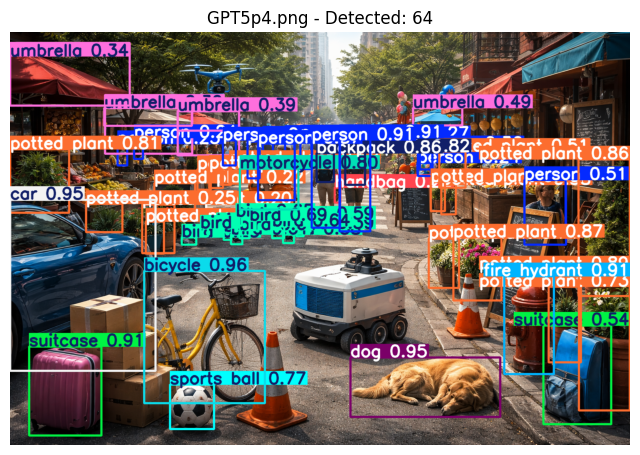

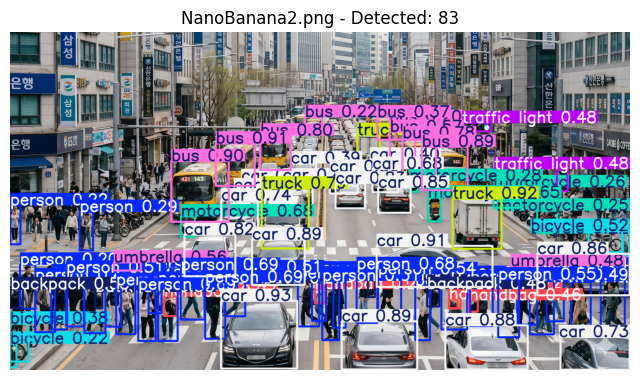

In [1]:
from ultralytics import YOLO
from pathlib import Path
import cv2
import matplotlib.pyplot as plt

image_path = sorted([p for p in Path(".").glob("*.png")])

model = YOLO("yolo26x.pt")
result = model.predict(image_path, conf=0.2)

# 출력
for i, p in enumerate(image_path):
    print(f"{p.name}: {len(result[i].boxes)} objects")

# 시각화
for i, res in enumerate(result):
    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(res.plot(), cv2.COLOR_BGR2RGB))
    plt.title(f"{image_path[i].name} - Detected: {len(res.boxes)}")
    plt.axis('off')
    plt.show()

## 7주차: Linear System

선형 시스템 상태공간 표현을 1D Mass-Spring-Damper와 2D 등가속도(CA) 모델로 구현한다.

**핵심 포인트**
- 연속시간: $\dot{\mathbf{X}}=A\mathbf{X}+B\mathbf{u}$, 이산시간: $\mathbf{X}_{k+1}=F\mathbf{X}_k+G\mathbf{u}_k$, 측정: $\mathbf{Y}_k=H\mathbf{X}_k$
- Forward Euler 이산화: $F=I+\Delta t\,A$, $G=\Delta t\,B$
- Stability(이산): 모든 $|\lambda(F)|<1$
- Controllability: $[B,\,AB,\,\dots,\,A^{n-1}B]$ rank = n
- Observability: $[H;\,HA;\,\dots;\,HA^{n-1}]$ rank = n

### 1. 1D MSD: A, B 행렬

연속시간 $\dot{\mathbf{x}}=A\mathbf{x}+Bu$. 상태 $[x,\dot{x}]^T$, 입력 $u$.

In [ ]:
import numpy as np

M, C, K, DT = 1.0, 1.2, 20.0, 0.01

A_1D = np.array([[0, 1],
                 [-K/M, -C/M]])
B_1D = np.array([[0],
                 [1/M]])

F_1D = np.eye(2) + DT * A_1D
G_1D = DT * B_1D

H_1D = np.array([[1.0, 0.0]])

### 2. dt 스윕용 이산 F, G 직접 정의

연속 A, B를 거치지 않고 바로 이산 형태로 작성.

In [ ]:
def run_msd_sim(dt, t_end=10.0, m=1.0, c=1.2, k=20.0):
    # 주어진 샘플링 시간에 대한 시간축 생성
    t = np.arange(0.0, t_end + dt, dt)
    n = len(t)

    # 연속시간 A, B를 거치지 않고 바로 이산 이행행렬 F, 입력행렬 G를 정의
    F = np.array([[1, dt],
                  [-k/m*dt, 1-c/m*dt]])
    G = np.array([[0],
                  [dt/m]])
    H = np.array([[1, 0]])

    u = np.zeros(n)
    u[(t >= 0.5) & (t < 2.5)] = 5.0
    u[(t >= 2.5) & (t < 5.0)] = -3.0
    u[(t >= 5.0)] = 0.0

    x = np.zeros((2, n))
    y = np.zeros(n)
    x[:, 0] = [0.0, 0.0]
    y[0] = (H @ x[:, 0])[0]

    for idx in range(1, n):
        x[:, idx] = F @ x[:, idx - 1] + G[:, 0] * u[idx - 1]
        y[idx] = (H @ x[:, idx])[0]

    return t, u, x, y


### 3. 감쇠계수 c 스윕 — 이산 F, G 재구성

$F = I + \Delta t A$, $G = \Delta t B$ (Forward Euler).

이산 시스템 $\mathbf{x}_{k+1}=F\mathbf{x}_k+G\mathbf{u}_k,\ \mathbf{y}_k=H\mathbf{x}_k$에서:

- **Stability (asymptotic)**: 모든 $|\lambda(F)|<1$ — 연속에서는 $\mathrm{Re}(\lambda(A))<0$
- **Controllability**: $\mathcal{C}=[G,\,FG,\,F^2G,\,\dots,\,F^{n-1}G]$의 rank = n
- **Observability**: $\mathcal{O}=[H;\,HF;\,HF^2;\,\dots;\,HF^{n-1}]$의 rank = n

MSD에서 감쇠 $c=0$이면 에너지 소산 없음 → 불안정 (stable=False). 2D CA는 $\lambda(F)=1$ 중근이라 한계안정(stable=False)이지만 ctrb/obsv는 모두 만족.

In [ ]:
import numpy as np
def ctrb_mat(A, B):
    n = A.shape[0]
    blocks, Ak = [B], np.eye(n)
    
    for _ in range(1, n):
        Ak = Ak @ A
        blocks.append(Ak @ B)
    return np.hstack(blocks)

def obsv_mat(A, H):
    n = A.shape[0]
    blocks, Ak = [], np.eye(n)
    
    for _ in range(n):
        blocks.append(H @ Ak)
        Ak = Ak @ A
    return np.vstack(blocks)

def analyze(A, B, H, tol=1e-9):
    eig = np.linalg.eigvals(A)
    stable = np.all(np.abs(eig) < 1.0 - tol)
    ctrb   = np.linalg.matrix_rank(ctrb_mat(A, B), tol) == A.shape[0]
    obsv   = np.linalg.matrix_rank(obsv_mat(A, H), tol) == A.shape[0]
    return eig, stable, ctrb, obsv

M, C, K, DT = 1.0, 1.2, 20.0, 0.01
H_1D = np.array([[1.0, 0.0]])
print("C    max_lamda    stable    control    observe")
for c_val in [0.0, 1.2, 5.0, 25.0]:
    F_t = np.array([[1.0, DT], [DT * (-K/M), 1 - DT * (C/M)]])
    G_t = np.array([[0.0], [DT / M]])
    eig, st, ct, ob = analyze(F_t, G_t, H_1D)
    print(f'{c_val:5.2f}    {np.max(np.abs(eig)):8.5f}    {str(st):>6}    {str(ct):>5}    {str(ob):>5}')
    
        

### 4. 2D CA 모델: F, G, H 행렬

상태 $[x, y, v_x, v_y]^T$, 입력 $[a_x, a_y]^T$, 출력 $[x, y]^T$.

시뮬레이션 루프: 초기 상태 / 상태 전파 / 출력

$\mathbf{x}_{k+1}=F\mathbf{x}_k+G\mathbf{u}_k$, $\mathbf{y}_k=H\mathbf{x}_k$

In [ ]:
delta_t = 0.1

F = np.array([[1, 0, delta_t, 0],
              [0, 1, 0, delta_t],
              [0, 0, 1, 0],
              [0, 0, 0, 1]])

G = np.array([[0.5*delta_t**2, 0],
              [0, 0.5*delta_t**2],
              [delta_t, 0],
              [0, delta_t]])

H = np.array([[1, 0, 0, 0],
              [0, 1, 0, 0]])

time = np.arange(0.0, 30.0 + delta_t, delta_t)
N = len(time)

acceleration = np.zeros((2, N))
for idx in range(N):
    t = time[idx]
    if t < 10:    acceleration[:, idx] = [2, 2]
    elif t < 20:  acceleration[:, idx] = [4, 4]
    else:         acceleration[:, idx] = [2, 2]

state = np.zeros((4, N))
output = np.zeros((2, N))

for idx in range(N):
    if idx == 0:
        state[:, idx] = [1.0, 1.0, 0.0, 0.0]   # 초기 상태
    else:
        state[:, idx] = F @ state[:, idx-1] + G @ acceleration[:, idx-1]
    output[:, idx] = H @ state[:, idx]

print(f'최종 상태 : {state[:, -1]}')
print(f'최종 출력 : {output[:, -1]}')